# Introduction

## The skyrmion

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def skyrmion_ansatz(b, nx, ny):
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    """
    X, Y = np.zeros((nx,ny)), np.zeros((nx,ny))
    for i in range(nx):
        for j in range(ny):
            X[i,j] = i
            Y[i,j] = j
        #end
    #end
    """
    X,Y = np.meshgrid(1.0*np.arange(nx),1.0*np.arange(ny))

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    #rescale
    X *= 1/b; Y *= 1/b
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = 2*X/(1+X**2+Y**2)
    n[1,:,:] = 2*Y/(1+X**2+Y**2)
    n[2,:,:] = (X**2+Y**2-1)/(X**2+Y**2+1)
    return n
#end

def ferromagnetic(nx,ny):
    n = np.zeros((3,nx,ny))
    n[2,:,:] = 1.0
    return n
#end

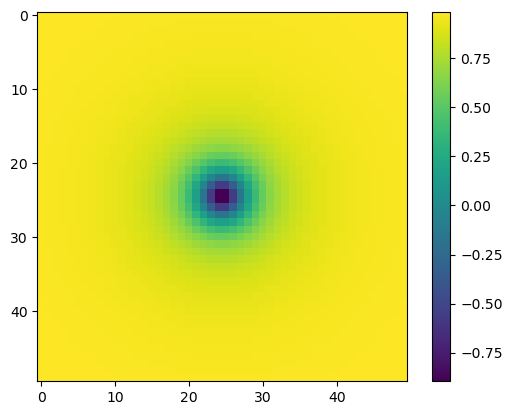

In [113]:
n = skyrmion_ansatz(3.0, 50,50)
plt.imshow(n[2,:,:])
plt.colorbar()

In [114]:
def topological_charge(n):
    m_x, m_y, m_z = n[0,:,:], n[1,:,:], n[2,:,:]

    # Compute partial derivatives
    dx = 1; dy = 1
    dmx_dx, dmx_dy = np.gradient(m_x, dx, dy, edge_order=2)
    dmy_dx, dmy_dy = np.gradient(m_y, dx, dy, edge_order=2)
    dmz_dx, dmz_dy = np.gradient(m_z, dx, dy, edge_order=2)

    # Calculate skyrmion density
    cross_x = dmy_dx * dmz_dy - dmz_dx * dmy_dy
    cross_y = dmz_dx * dmx_dy - dmx_dx * dmz_dy
    cross_z = dmx_dx * dmy_dy - dmy_dx * dmx_dy

    density = m_x * cross_x + m_y * cross_y + m_z * cross_z
    Q = (1 / (4 * np.pi)) * np.sum(density) * dx * dy
    
    return Q, density    

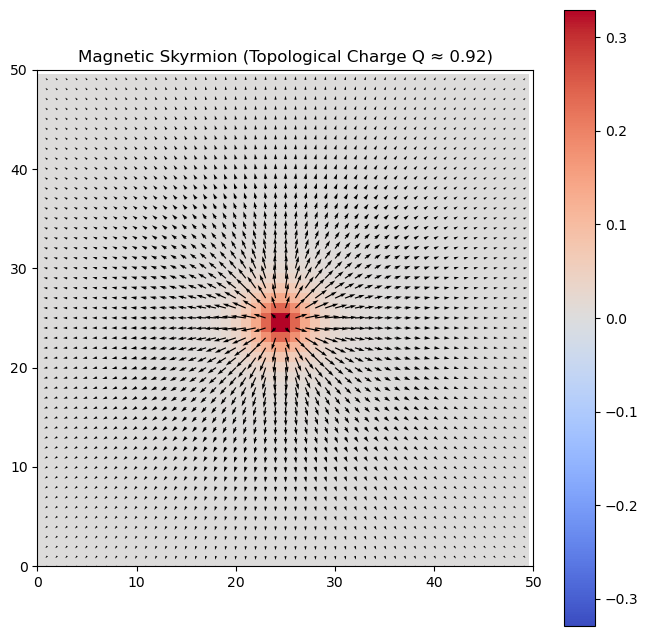

In [115]:
def show(n):
    plt.figure(figsize=(8, 8))
    plt.quiver(n[0,:,:], n[1,:,:])
    x0 = 0; x1 = n.shape[1]
    plt.xlim(x0,x1); plt.ylim(x0,x1)

    Q, density = topological_charge(n)
    max_d = np.max(np.abs(density))
    plt.imshow(density, cmap='coolwarm',vmin=-max_d, vmax=max_d)
    plt.title(f'Magnetic Skyrmion (Topological Charge Q ≈ {Q:.2f})')
    plt.colorbar()

show(n)

In [116]:
def H_vect(n,J1,J2,J3,K,B):
    E = 0
    nx = n.shape[1]; ny = n.shape[2]
    for i in range(nx):
        for j in range(ny):
            n_a = n[:,i,j]
            #account for the anisotropy
            E -= K*n_a[2]**2
            #add external field
            E -= B[i,j]*n_a[2]
            for (k,l) in [(i+1,j),(i,j+1)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J1*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J2*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+2,j),(i,j+2)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J3*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
        #end
    #end
    E += np.sum(B)+nx*ny*(K+2*J1+2*J2+2*J3) #subtract the energy of the FM state
    return E
#end

def B_uniform(nx,ny,B_val, rim=True,rim_val=0.5):
    B = B_val*np.ones((nx,ny))
    if rim:
        large_B = rim_val
        B[0,:] = large_B; B[-1,:] = large_B
        B[:,0] = large_B; B[:,-1] = large_B
    return B*np.ones((nx,ny))
#end

def local_B_field(nx,ny,B_val,r,sigma=1.0):
    X,Y = np.meshgrid(1.0*np.arange(nx),1.0*np.arange(ny))
    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    R = np.sqrt(X**2+Y**2)

    return B_val*( (R<=r) + (R>=r)*np.exp(-(R-r)**2/sigma**2) )


n = ferromagnetic(50,37)
H_vect(n,1.0, -0.2, -0.1, 0.2, B_uniform(50,37,1.23))

2.2737367544323206e-11

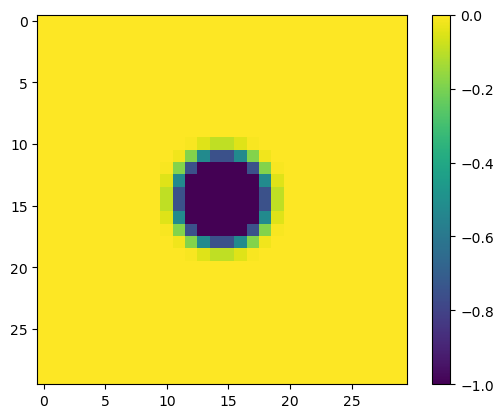

In [117]:
plt.imshow(local_B_field(30,30,-1.0,3.0))
plt.colorbar()

Text(0, 0.5, '$E-E_{FM}$')

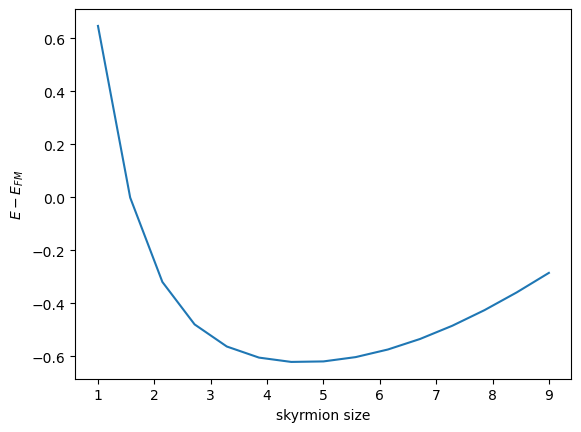

In [118]:
nx = 50; ny =50
#J1 = 1.0; J2 = -0.25; J3 = -0.10; B = -0.006
J1 = 1.0; J2 = -0.30; J3 = -0.20; K =0*1E-5; B = B_uniform(nx,ny,0.001, rim=False) + local_B_field(nx,ny,-0.020,r=3.0,sigma=1.0)
#J1 = 1.0; J2 = -0.25; J3 = -0.20; B = 0.0
nx = 30; ny =30

b_vals = np.linspace(1.0,9,15)
H_vals = []
for b in b_vals:
    n = skyrmion_ansatz(b, nx, ny)
    E = H_vect(n,J1,J2,J3,K,B)
    H_vals.append(E)
#end

plt.plot(b_vals,H_vals)
plt.xlabel("skyrmion size"); plt.ylabel("$E-E_{FM}$")

A BIG problem might be that in a uniform setting, if a skyrmion detects algebraically, the contribution from boundary conditions might carry a lot of weight !

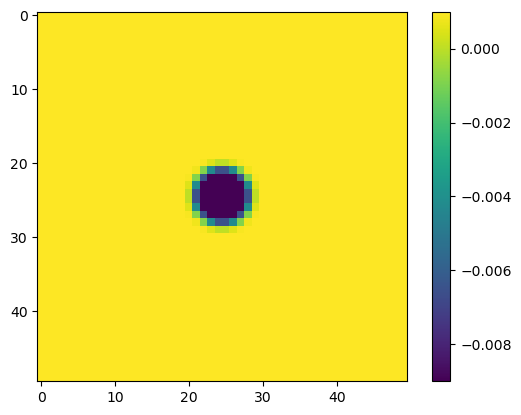

In [84]:
plt.imshow(B)
plt.colorbar()

In [85]:
np.sqrt( (J1+4*J2+16*J3) / (J1+2*J2+4*J3) )

2.9154759474226504

In [87]:
b_vals = np.linspace(1.0,5,12)
H_vals = []
for b in b_vals:
    n = skyrmion_ansatz(b, nx, ny)
    E = H_vect(n,J1,J2,J3,K,B)
    H_vals.append(E)
#end
b_vals[np.argmin(H_vals)]

3.909090909090909

## Relaxation dynamics

To minimize the energy, we would like to perform gradient descent on $n$ :
$$
\dot{n} = - \nabla_n H
$$
But this would be unphysical as we need to ensure $|n|=1$. To fix the issue, we simply subtract from the RHS the part proportional to $n$, obtaining
$$
\dot{n} = -\nabla_n H + (n \cdot \nabla_n H) \; n
$$
so that $n \dot{n} = 0$.


Maybe a ($n^2=1$ constrained) variant of Newton's method could be used? The Hessian is easy enough to compute, since $H$ is quadratic in $n$.

staring from a hedgehog of size  3.909090909090909


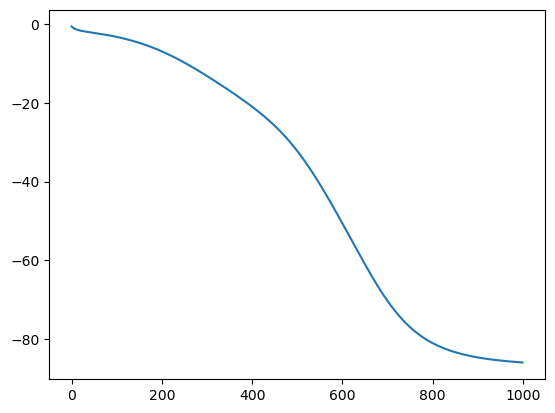

In [88]:
def relax(n_init, nx, ny, J1, J2, J3, K, B, dt, N_steps):
    """
    Gradient descent on H
    """
    def F(n,nx,ny,J1,J2,J3,K,B):
        g = np.zeros_like(n) # MINUS the gradient of H
        for i in range(nx):
            for j in range(ny):
                #external field
                g[2,i,j] += B[i,j]
                #anisotropy
                g[:,i,j] += 2*K*n[:,i,j]

                for (k,l) in [(i+1,j),(i,j+1)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J1* n[:,k,l]
                    g[:,k,l] += J1* n[:,i,j]

                for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J2* n[:,k,l]
                    g[:,k,l] += J2* n[:,i,j]

                for (k,l) in [(i+2,j),(i,j+2)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J3* n[:,k,l]
                    g[:,k,l] += J3* n[:,i,j]
            #end
        #end

        for i in range(nx):
            for j in range(ny):
                gn = n[0,i,j]*g[0,i,j] + n[1,i,j]*g[1,i,j] + n[2,i,j]*g[2,i,j]
                g[:,i,j] = g[:,i,j] - gn*n[:,i,j]
        return g
    #endfunction


    n = np.zeros_like(n_init)
    H_vals = np.zeros(N_steps)
    n = n_init
    for i in range(N_steps):
        k1 = F(n, nx, ny, J1, J2, J3, K, B)
        #adaptive time step
        #maxf = np.max(np.abs(k1))
        #dt = 5E-2/ maxf
        #print("dt = ", dt)
        n += k1*dt
        H_vals[i] = H_vect(n,J1,J2,J3,K,B)
    
    plt.plot(H_vals)
    return n
#end

def skyrmion_minimum(nx, ny, J1, J2, J3, K, B, dt=0.05, N_steps=50):
    
    #see what kind of skyrmion has optimal size
    b_vals = np.linspace(1.0,5,12)
    H_vals = []
    for b in b_vals:
        n = skyrmion_ansatz(b, nx, ny)
        E = H_vect(n,J1,J2,J3,K,B)
        H_vals.append(E)
    #end
    b = b_vals[np.argmin(H_vals)]
    print("staring from a hedgehog of size ", b)

    return relax(skyrmion_ansatz(b,nx,ny),nx,ny,J1,J2,J3,K,B,dt,N_steps)
    

n_Sk = skyrmion_minimum(nx,ny,J1,J2,J3,K,B,dt=0.05,N_steps=1000)

In [89]:
def check_norm(n):
    norm = n[0,:,:]**2 + n[1,:,:]**2 + n[2,:,:]**2
    print("norm varies from", np.min(norm), "to", np.max(norm))
check_norm(n_Sk)

norm varies from 1.0000000050606093 to 1.0001104962395835


A square lattice of skyrmions is destabilized by a magnon excitation.

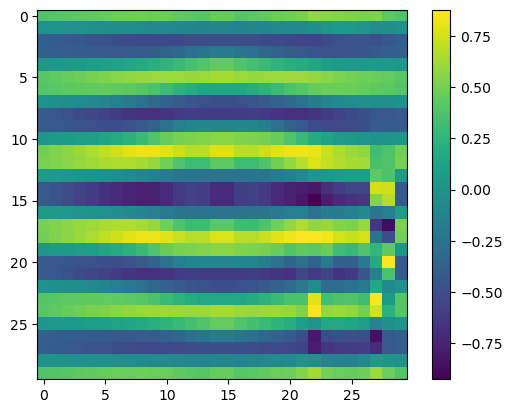

In [90]:
plt.imshow(n_Sk[2,:,:])
plt.colorbar()

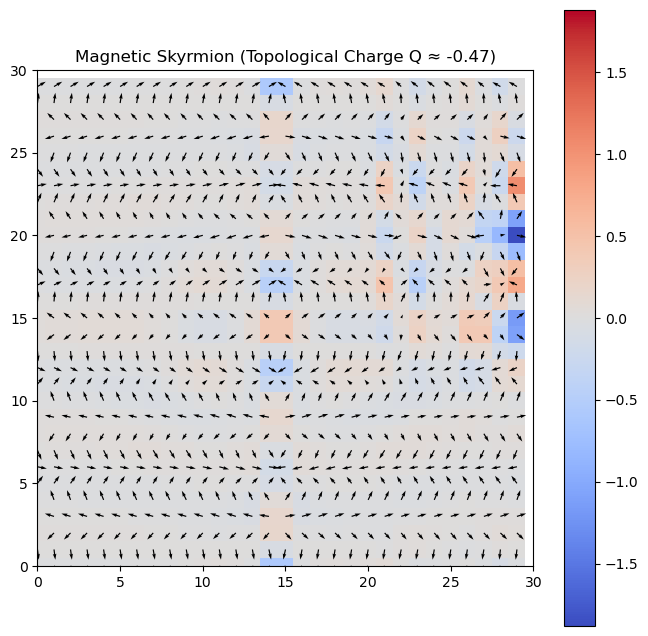

In [91]:
show(n_Sk)

## Sterographic projection and the Hamiltonian

$$
n_x = \frac{w + \bar{w}}{1+\bar{w}w} \qquad n_y = -i \frac{w - \bar{w}}{1+\bar{w}w} \qquad n_z = \frac{1-\bar{w}w}{1+\bar{w}w} 
$$

The inverse mapping is

$$
|w|^2 = \frac{1-n_z}{1+n_z} \qquad w = \frac{n_x + i n_y}{1+n_z}
$$

In [29]:
def w_project(n):
    w = np.zeros((n.shape[1], n.shape[2]),dtype=complex)
    w = (n[0,:,:]+ 1j*n[1,:,:]) / (1+n[2,:,:])
    return w
#end

def n_vector(w):
    n = np.zeros((3, w.shape[0], w.shape[1]))
    n[0,:,:] = np.real( (w + np.conj(w)) / (1 + np.conj(w)*w) )
    n[1,:,:] = np.real(-1j * (w - np.conj(w)) / (1 + np.conj(w)*w))
    n[2,:,:] = np.real((1-w*np.conj(w)) / (1 + np.conj(w)*w))
    return n
#end

In [30]:
def w(w0, lbd):
    return np.real(w0) + 1j*lbd*np.imag(w0)

def n_lbd(w0, lbd):
    return n_vector(w(w0,lbd))

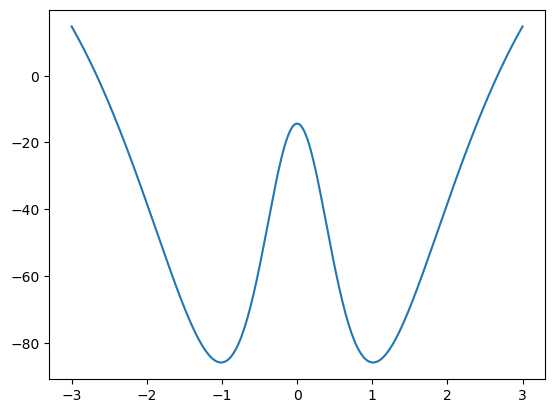

In [93]:
w0 = w_project(n_Sk)
lbd_vals = np.linspace(-3.0, 3.0, 301)
H_vals = []
for lbd in lbd_vals:
    n = n_vector(w(w0,lbd))
    #check_norm(n)
    H_vals.append(H_vect(n,J1,J2,J3,K,B))
plt.plot(lbd_vals,H_vals)


I need to
1. Test my H function
2. Make sure gradient-descent works well
3. Visualize and understand the configurations.
4. Scrutinize the choice of parameters (consider adding anisotropy, too!)

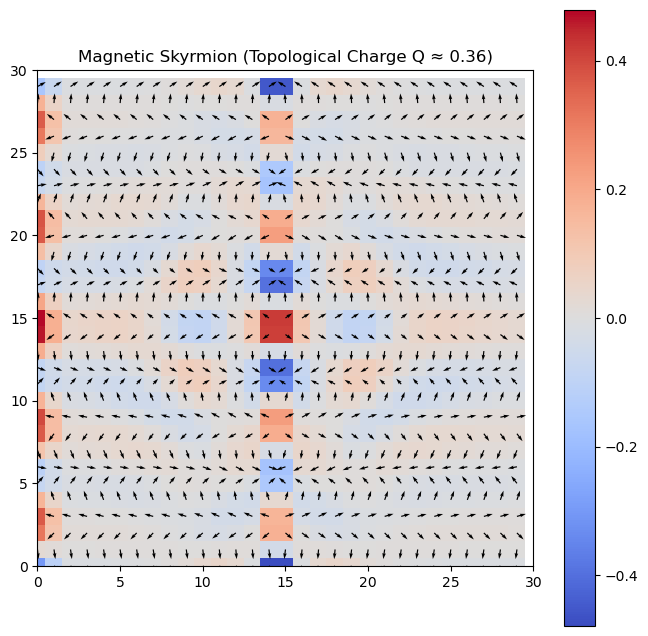

In [ ]:
w0 = 
show(n_vector(w(w0,lbd=1.0)))